# Qualitatively Evaluate Models
Pull trained model weights down from s3, load, and infer

In [12]:
# Mike Zelinski did not write this code. But he understands it. 

import sys, os
sys.path.append(os.path.abspath('../src'))

In [13]:
!pip install -r ../src/requirements.txt

In [14]:

from llnl_ml.model.unet import UNet
from llnl_ml.lightning import SegmentationLightningModule

import torch

from llnl_ml.data import get_data_loaders

import matplotlib.pyplot as plt

In [15]:
image_folder = r"C:\\Users\\zelinski1\\Desktop\\work\\Thrust2\\data\\t240418\\images\\"
mask_folder = r"C:\\Users\\zelinski1\\Desktop\\work\\Thrust2\\data\\t240418\\masks\\"
batch_size = 4
num_workers = 2
image_mode = "L"

n_batches = 1

In [16]:
# Downloaded the model.tar.gz file from S3 and upacked in terminal
#aws s3 cp s3://sagemaker-us-west-2-159929462505/pytorch-training-2024-01-25-17-38-38-640/output/model.tar.gz ../models/
#tar -xf model.tar.gz


In [17]:

model_type = "other"

if model_type == "17k":
    model_dir = "..\models\\17k_dataset"
    model_name = "epoch=23-val_loss=0.091.ckpt"

if model_type == "2k":
    model_dir = "..\models\\2k_dataset"
    model_name = "last.ckpt"
else:
    model_dir = "..\models\\test-count-8-13446-it0-240419-1930"
    model_name = "epoch=08-val_loss=0.118.ckpt"

checkpoint_path = f"{model_dir}\{model_name}"
#print( checkpoint_path )
print( '{} is a file: '.format(checkpoint_path, os.path.isfile(checkpoint_path)))


..\models\test-count-8-13446-it0-240419-1930\epoch=08-val_loss=0.118.ckpt is a file: 


In [18]:
# By default, pytorch lightning will save the state_dict of the Lightning Module
# Create the model and PL Module wrapping it, load the state_dict into the PL module which will
# also load the underying model inside.
pl_model = SegmentationLightningModule.load_from_checkpoint(checkpoint_path)
model = pl_model.model
model.eval()

UNet(
  (conv1): DoubleConv(
    (double_conv): Sequential(
      (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (down_conv): ModuleList(
    (0): DownConv(
      (down_conv): Sequential(
        (0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        (1): DoubleConv(
          (double_conv): Sequential(
            (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (1): ReLU(inplace=True)
            (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (3): ReLU(inplace=True)
          )
        )
      )
    )
    (1): DownConv(
      (down_conv): Sequential(
        (0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        (1): DoubleConv(
          (double_conv): Sequential(
            (

In [19]:
    train_loader, val_loader, test_loader = get_data_loaders(
        image_folder=image_folder,
        mask_folder=mask_folder,
        batch_size=batch_size,
        num_workers=num_workers,
        image_mode=image_mode,
        image_size=1200,
        use_random_resize=False,
        use_random_rotate=False,
        color_jitter=0.0,
        center_crop=True,
        center_crop_size=1200,
        center_crop_offset=(-60, -50),
    )

In [20]:
def plot_batch_results(images, masks, results, fname=None):
    n_plots = images.shape[0]
    fig, axs = plt.subplots(n_plots, 4, figsize=(12,12))
    # Add titles
    axs[0, 0].set_title("Input Image")
    axs[0, 1].set_title("Mask")
    axs[0, 2].set_title("Raw Output")
    axs[0, 3].set_title("Thresholded Output")
    for row in range(images.shape[0]):
        axs[row, 0].imshow(images[row], cmap="gray")
        axs[row, 0].set_axis_off()
        axs[row, 1].imshow(masks[row])
        axs[row, 1].set_axis_off()
        axs[row, 2].imshow(results[row])
        axs[row, 2].set_axis_off()
        axs[row, 3].imshow(results[row] > 0)
        axs[row, 3].set_axis_off()
    fig.subplots_adjust(wspace=0, hspace=0)
    if fname:
        plt.savefig(fname, bbox_inches="tight")

(2, 1200, 1200)
(2, 1200, 1200)
(2, 1200, 1200)
0.044900518
Batch 0: loss_fn(output.squeeze(), test_batch[1]['masks']) = tensor(0.0449)


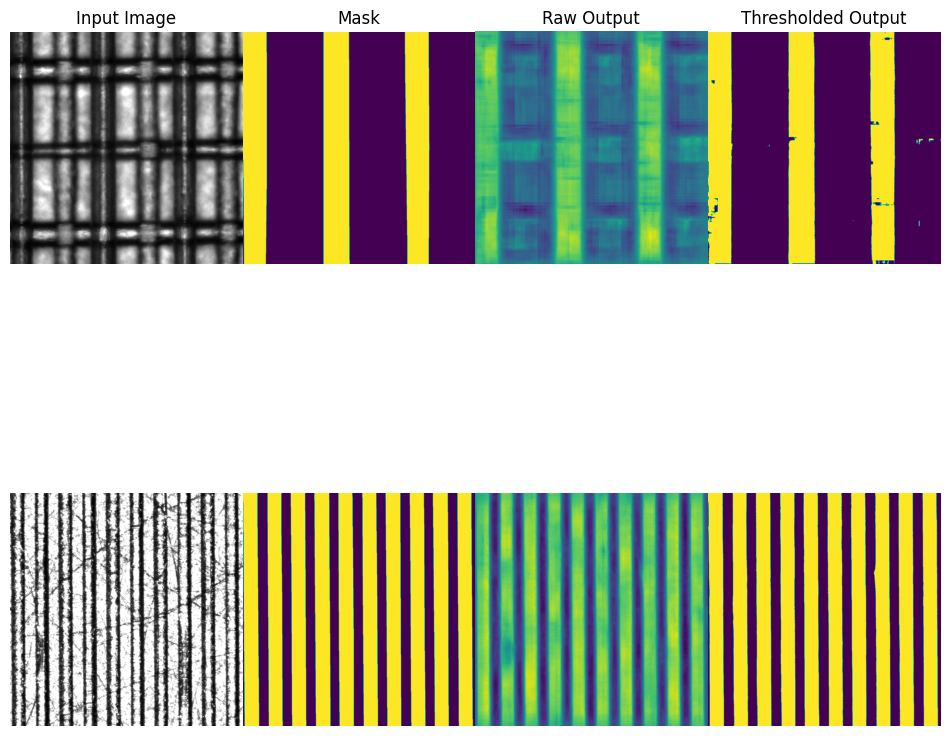

In [21]:
# For simple testing, grab the first batch of test and train so we 
# can see the performance difference
loss_fn = torch.nn.BCEWithLogitsLoss()
for batch_count, test_batch in enumerate(test_loader):
    if batch_count >= n_batches:
        break
    with torch.no_grad():
        output = model(test_batch[0])
        result = output.detach().squeeze().numpy()
        images = test_batch[0].squeeze().numpy()
        print( images.shape )
        masks = test_batch[1]['masks'].squeeze().numpy()
        print( result.shape )
        print( masks.shape )
    filename = f"{model_dir}/test_{images.shape[-1]}_batch{batch_count}.png"
    plot_batch_results(images, masks, result, fname=filename)
    print( loss_fn(output.squeeze(), test_batch[1]['masks']).detach().squeeze().numpy() )
    print(f"Batch {batch_count}: {loss_fn(output.squeeze(), test_batch[1]['masks']) = }")

Batch 0: loss_fn(output.squeeze(), train_batch[1]['masks']) = tensor(0.0830)


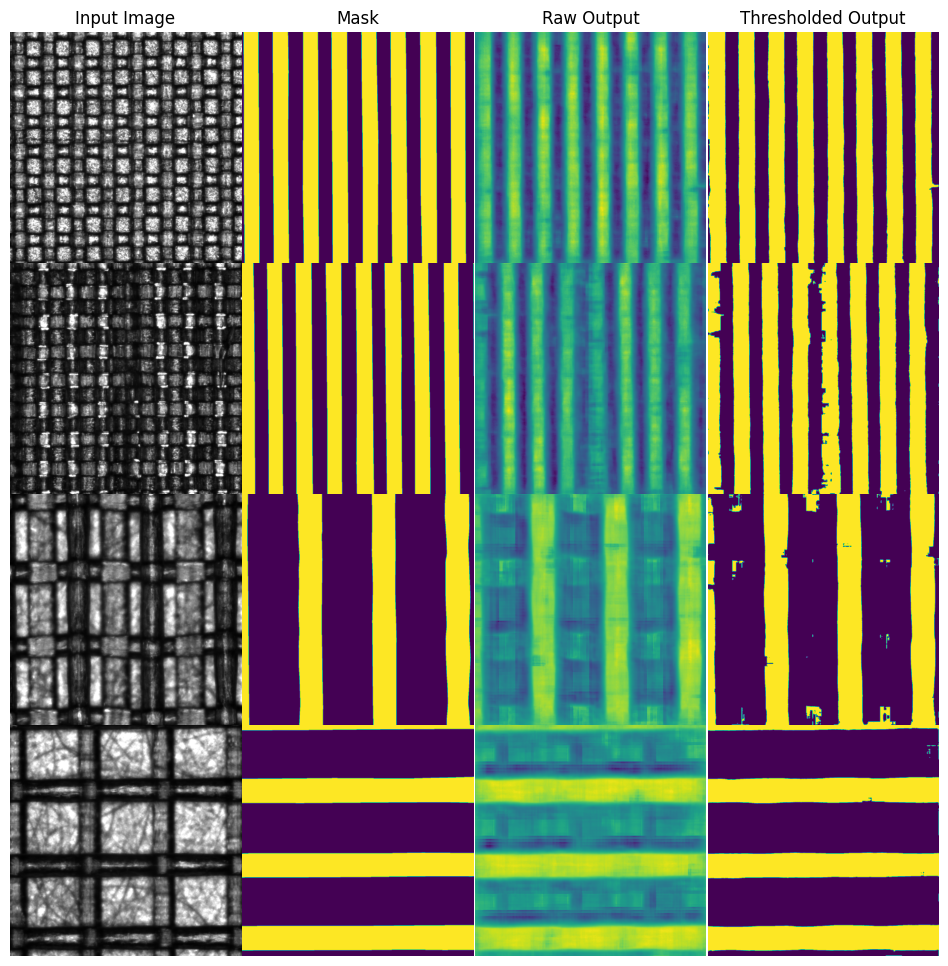

In [22]:
for batch_count, train_batch in enumerate(train_loader):
    if batch_count >= n_batches:
        break
    with torch.no_grad():
        output = model(train_batch[0])
        result = output.detach().squeeze().numpy()
        images = train_batch[0].squeeze().numpy()
        masks = train_batch[1]['masks'].squeeze().numpy()
    filename = f"{model_dir}/train_{images.shape[-1]}_batch{batch_count}.png"
    plot_batch_results(images, masks, result, fname=filename)
    print(f"Batch {batch_count}: {loss_fn(output.squeeze(), train_batch[1]['masks']) = }")


Use this portion of the code for just performing inference
